<div align="center" markdown="1" style="color: black; background-color: #c9d0d6; padding: 10px; margin: 10px 0; border-radius: 4px;">
    <div style="font-size: 25px;">
      Reconstrução de superficies a partir de nuvem de pontos
    </div>
    <div style="font-size: 15px;">
        Trabalho da disciplina de Otimização Não Linear - ICMC USP
    </div>
    <p>
    <div style="font-size: 17px;">
        Guilherma da Mata (da maaataaa hahaha já escutou aquela musica?) Garzon - <br/>
        Pedro Poiani - <br/>
        Vinícius (Ahhh Araujo?) Arcanjo Fonseca de Oliveira - 15589586 <br/>
        Vinícius de Sá - <br/>
    </div>
</div>

<p>



Esse projeto foi fortemente inspirado no trabalho [Points as Tori: Fast Pointwise Signed Distance for Point Clouds](https://nzfeng.github.io/research/PointsAsTori/) de [Nicole Feng](https://nzfeng.github.io/), [Ioannis Gkioulekas](www.cs.cmu.edu/~igkioule/) e [Keenan Crane](https://www.cs.cmu.edu/~kmcrane/).<br>

O processo para a reconstrução de superficies se baseia em subdividir a nuvem de pontos em grupos e encontrar [*superficies algebricas*](https://en.wikipedia.org/wiki/Algebraic_surface) que diminuem o erro quadratico dado pela distancia entre o grupo de pontos a superficie algebrica. Disso, utilizamos uma heuristica para determinar uma aproximação para a [*Função de Distância Associada*](https://en.wikipedia.org/wiki/Signed_distance_function) da nuvem de pontos inicial, com essa aproximação podemos finalizar a reconstrução de superifície.<br>

In [4]:
#from manim import *
import numpy as np
import open3d as o3d
import trimesh
import pyvista as pv


from scipy.spatial import cKDTree
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN

from scipy.optimize import least_squares
import jax
import jax.numpy as jnp
# import torch

from skimage.measure import marching_cubes

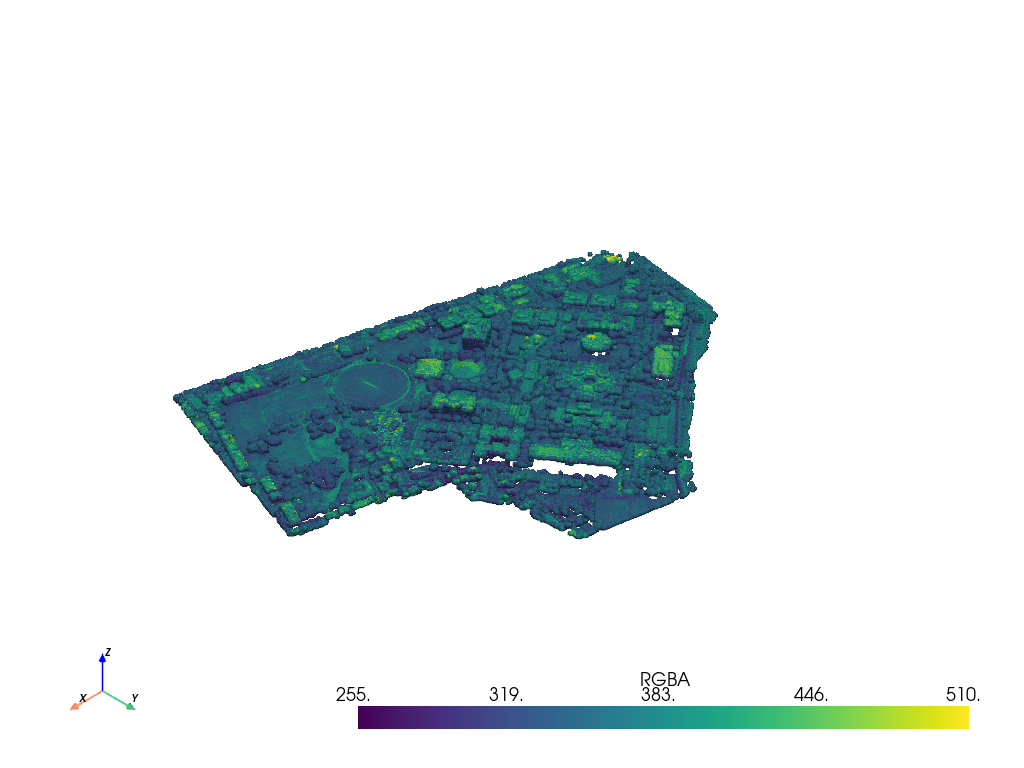

In [5]:
import pyvista as pv

data = pv.read("LUMS_F6_09NOV2016 - Modified.ply")

data.plot(
    jupyter_backend="static", 
    point_size=5.0, 
    render_points_as_spheres=True,
    show_axes=True
)

Antes de começarmos o processo, realizamos a importação do conjunto de dados das nuvens de pontos.

https://www.kaggle.com/datasets/ahmadkamalnasir/3d-point-clouds


https://www.kaggle.com/datasets/sordi-ai/industrial-point-cloud-part-01-dataset
https://www.kaggle.com/datasets/kmader/point-cloud-segmentation/data
https://www.kaggle.com/code/dnyaneshwalwadkar/3d-pointcloud-classification-a-comprehensive-guide
